In [1]:
# Cell 1: Libraries and System Parameter Configuration
from pathlib import Path
import wave
import numpy as np
import matplotlib.pyplot as plt

# Dataset directory paths
TRAIN_DIR = Path("../../TinHieuHuanLuyen")
TEST_DIR = Path("../../TinHieuKiemThu")
OUTPUT_DIR = Path("output/main")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# DSP parameters according to project specifications
FRAME_MS = 25        # Frame length in milliseconds (ms)
HOP_MS = 10          # Frame hop size in milliseconds (ms)
MIN_SILENCE_MS = 200 # Minimum silence duration (ms) to filter spurious pauses


In [2]:
# Cell 2: Fundamental Audio Processing Functions (Read WAV, Read LAB, Compute STE)
def read_wav(wav_path):
    """
    Read a 16-bit PCM WAV file, normalize amplitude to [-1, 1], and extract sample rate and peak amplitude.

    Parameters:
        wav_path (Path or str): Path to the WAV audio file.

    Returns:
        signal (np.ndarray): Normalized floating-point audio signal scaled to [-1, 1].
        fs (int): Sampling rate (Hz).
        max_amp (float): Maximum absolute amplitude of the original raw signal.
    """
    with wave.open(str(wav_path), "rb") as wf:
        fs = wf.getframerate()
        samples = wf.readframes(wf.getnframes())
    signal = np.frombuffer(samples, dtype=np.int16).astype(float)
    max_amp = np.max(np.abs(signal))
    return signal / max_amp, fs, max_amp


def read_lab(lab_path):
    """
    Read a .lab annotation file and return ground-truth speech boundaries (start, end) covering voiced (v) and unvoiced (uv).

    Parameters:
        lab_path (Path or str): Path to the .lab annotation file.

    Returns:
        start_time (float): Ground-truth start timestamp in seconds.
        end_time (float): Ground-truth end timestamp in seconds.
    """
    speech = []
    for line in lab_path.read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) == 3 and parts[2].lower() in {"v", "uv"}:
            speech.append((float(parts[0]), float(parts[1])))
    return round(min(s[0] for s in speech), 4), round(max(s[1] for s in speech), 4)


def compute_ste(signal, fs, frame_ms=FRAME_MS, hop_ms=HOP_MS):
    """
    Segment the signal into overlapping frames and compute normalized Short-Time Energy (STE) in [0, 1].

    Parameters:
        signal (np.ndarray): Normalized input audio signal.
        fs (int): Sampling rate (Hz).
        frame_ms (float): Frame duration in milliseconds (default: FRAME_MS).
        hop_ms (float): Frame step / hop size in milliseconds (default: HOP_MS).

    Returns:
        ste_norm (np.ndarray): Short-Time Energy array normalized to range [0, 1].
        frame_starts (np.ndarray): Starting timestamp (seconds) of each frame.
        max_ste (float): Maximum unnormalized energy value across all frames.
    """
    # 1. Compute frame length, hop size in samples, and total number of frames
    frame_size = int(round(frame_ms * fs / 1000.0))
    hop_size = int(round(hop_ms * fs / 1000.0))
    n_frames = max(1, int(np.ceil(max(0, len(signal) - frame_size) / hop_size)) + 1)

    # 2. Extract frames and compute mean squared energy for each frame
    ste = np.zeros(n_frames)
    frame_starts = np.zeros(n_frames)
    for i in range(n_frames):
        start = i * hop_size
        frame = np.zeros(frame_size)
        avail = signal[start : min(start + frame_size, len(signal))]
        frame[:len(avail)] = avail
        ste[i] = np.mean(frame ** 2)
        frame_starts[i] = start / fs

    # 3. Normalize STE to [0, 1] relative to peak energy
    max_ste = float(np.max(ste))
    ste_norm = ste / max(max_ste, 1e-12)
    return ste_norm, frame_starts, max_ste


In [3]:
# Cell 3: VAD Binary Search Model & Training (Epoch Logging, MAE, RMSE, Threshold T, and Unnormalization)
class EnergyBinarySearchVAD:
    """
    Voice Activity Detection (VAD) model optimizing Short-Time Energy threshold via Binary Search.
    Objective function: eliminate the signed duration error of total predicted speech
    relative to ground-truth labels across the training dataset.
    """
    def __init__(self, epochs=40, search_range=(1e-4, 0.05)):
        """
        Initialize the VAD binary search optimizer.

        Parameters:
            epochs (int): Number of binary search iterations.
            search_range (tuple): Search interval (low, high) for normalized threshold T.
        """
        self.epochs = epochs
        self.search_range = search_range
        self.threshold = None

    def predict(self, ste_norm, frame_starts, duration, threshold=None):
        """
        Classify frames using threshold T, bridge spurious silence gaps < 200 ms, and return (pred_start, pred_end).

        Parameters:
            ste_norm (np.ndarray): Normalized STE sequence in [0, 1].
            frame_starts (np.ndarray): Frame start timestamps in seconds.
            duration (float): Total audio duration in seconds.
            threshold (float, optional): Decision threshold. Defaults to self.threshold.

        Returns:
            bounds (tuple): Tuple of (pred_start, pred_end) in seconds.
            labels (np.ndarray): Frame-level binary labels (1 = speech, 0 = silence).
        """
        if threshold is None:
            threshold = self.threshold
        labels = (ste_norm >= threshold).astype(int)
        min_silence_frames = int(round(MIN_SILENCE_MS / HOP_MS))
        speech_idx = np.flatnonzero(labels == 1)
        if len(speech_idx) == 0:
            return (0.0, 0.0), labels

        # Fill internal silence intervals shorter than 200 ms within speech regions
        idx, last = int(speech_idx[0]), int(speech_idx[-1])
        while idx <= last:
            if labels[idx] == 1:
                idx += 1
            else:
                sil_start = idx
                while idx <= last and labels[idx] == 0:
                    idx += 1
                if idx - sil_start < min_silence_frames:
                    labels[sil_start:idx] = 1

        # Identify speech start and end boundary timestamps in seconds
        speech_idx = np.flatnonzero(labels == 1)
        start_time = float(frame_starts[speech_idx[0]])
        end_time = min(duration, float(frame_starts[speech_idx[-1]] + FRAME_MS / 1000.0))
        return (round(start_time, 4), round(end_time, 4)), labels

    def fit(self, train_data):
        """
        Train binary search narrowing interval [low, high], logging T, MAE, and RMSE across epochs.

        Parameters:
            train_data (list): List of training sample dictionaries.

        Returns:
            self: The fitted model instance.
        """
        low, high = self.search_range
        print(f"Starting binary search for STE threshold on interval [{low:.6f}, {high:.6f}] over {self.epochs} epochs:")
        print("-" * 96)
        for epoch in range(1, self.epochs + 1):
            threshold = (low + high) / 2.0
            duration_errors, maes, rmses = [], [], []
            for item in train_data:
                pred_bounds, _ = self.predict(item["ste_norm"], item["frame_starts"], item["duration"], threshold)
                pred_dur = pred_bounds[1] - pred_bounds[0]
                true_dur = item["gt_bounds"][1] - item["gt_bounds"][0]
                duration_errors.append(pred_dur - true_dur)
                d_st = (pred_bounds[0] - item["gt_bounds"][0]) * 1000.0
                d_en = (pred_bounds[1] - item["gt_bounds"][1]) * 1000.0
                maes.append((abs(d_st) + abs(d_en)) / 2.0)
                rmses.append(np.sqrt((d_st**2 + d_en**2) / 2.0))

            mean_error = float(np.mean(duration_errors))
            epoch_mae = float(np.mean(maes))
            epoch_rmse = float(np.mean(rmses))

            # Log epoch progress with T, duration discrepancy, training MAE, and RMSE
            if epoch <= 10 or epoch % 5 == 0 or epoch == self.epochs:
                print(f"Epoch {epoch:02d} | T = {threshold:.8f} | Discrepancy = {mean_error:+.4f} s | Train MAE = {epoch_mae:5.2f} ms | Train RMSE = {epoch_rmse:5.2f} ms")

            # If predicted speech is too long -> threshold is too low -> raise lower bound
            if mean_error > 0:
                low = threshold
            else:
                high = threshold

        self.threshold = (low + high) / 2.0
        print("-" * 96)
        print(f">>> OPTIMAL STE THRESHOLD FOUND: T = {self.threshold:.8f}")
        return self


# 1. Load and process all training recordings (Train Data)
train_data = []
for wav_file in sorted(TRAIN_DIR.glob("*.wav")):
    signal, fs, max_amp = read_wav(wav_file)
    ste_norm, frame_starts, max_ste = compute_ste(signal, fs)
    gt_bounds = read_lab(wav_file.with_suffix(".lab"))
    train_data.append({
        "name": wav_file.name,
        "ste_norm": ste_norm,
        "frame_starts": frame_starts,
        "duration": len(signal) / fs,
        "gt_bounds": gt_bounds,
        "max_amp": max_amp,
        "max_ste": max_ste,
    })

# 2. Instantiate and train the VAD binary search model
model = EnergyBinarySearchVAD(epochs=40)
model.fit(train_data)

# 3. Unnormalize threshold to physical scale of each training recording
print("\n>>> UNNORMALIZED THRESHOLDS IN PHYSICAL DOMAIN (Multiplied back with maximums):")
for item in train_data:
    t_raw_ste = model.threshold * item["max_ste"]
    t_amp = np.sqrt(model.threshold) * item["max_amp"]
    print(f"  {item['name']:<15} (max_amp = {item['max_amp']:>7.0f}, max_ste = {item['max_ste']:.4f}) -> Raw STE Threshold = {t_raw_ste:.6f} | Equivalent Amplitude = {t_amp:.1f}")


Starting binary search for STE threshold on interval [0.000100, 0.050000] over 40 epochs:
------------------------------------------------------------------------------------------------
Epoch 01 | T = 0.02505000 | Discrepancy = -0.0200 s | Train MAE = 13.75 ms | Train RMSE = 14.27 ms
Epoch 02 | T = 0.01257500 | Discrepancy = -0.0150 s | Train MAE = 11.25 ms | Train RMSE = 12.39 ms
Epoch 03 | T = 0.00633750 | Discrepancy = -0.0050 s | Train MAE = 10.00 ms | Train RMSE = 12.64 ms
Epoch 04 | T = 0.00321875 | Discrepancy = +0.0000 s | Train MAE = 12.50 ms | Train RMSE = 15.08 ms
Epoch 05 | T = 0.00477813 | Discrepancy = -0.0050 s | Train MAE = 10.00 ms | Train RMSE = 12.64 ms
Epoch 06 | T = 0.00399844 | Discrepancy = -0.0025 s | Train MAE = 11.25 ms | Train RMSE = 14.31 ms
Epoch 07 | T = 0.00360859 | Discrepancy = -0.0025 s | Train MAE = 11.25 ms | Train RMSE = 14.31 ms
Epoch 08 | T = 0.00341367 | Discrepancy = +0.0000 s | Train MAE = 12.50 ms | Train RMSE = 15.08 ms
Epoch 09 | T = 0.0035

In [4]:
# Cell 4: Model Evaluation on Test Dataset - Reporting MAE and RMSE (ms)
test_results = []
print("=" * 96)
print(f"{'QUANTITATIVE EVALUATION ON TEST DATASET (TEST EVALUATION)':^96}")
print("=" * 96)
print(f"{'File':<16} | {'Ground Truth (s)':<16} | {'Predicted (s)':<16} | {'ΔStart':<10} | {'ΔEnd':<10} | {'MAE (ms)':<9} | {'RMSE (ms)':<9}")
print("-" * 96)

for wav_file in sorted(TEST_DIR.glob("*.wav")):
    signal, fs, max_amp = read_wav(wav_file)
    duration = len(signal) / fs
    ste_norm, frame_starts, max_ste = compute_ste(signal, fs)
    gt = read_lab(wav_file.with_suffix(".lab"))
    pred, labels = model.predict(ste_norm, frame_starts, duration)

    # Compute boundary timing errors in milliseconds (ms)
    d_start = (pred[0] - gt[0]) * 1000.0
    d_end = (pred[1] - gt[1]) * 1000.0
    mae = (abs(d_start) + abs(d_end)) / 2.0
    rmse = np.sqrt((d_start**2 + d_end**2) / 2.0)

    test_results.append({
        "file": wav_file.name,
        "signal": signal,
        "fs": fs,
        "ste_norm": ste_norm,
        "frame_starts": frame_starts,
        "gt": gt,
        "pred": pred,
        "labels": labels,
        "d_start": d_start,
        "d_end": d_end,
        "mae": mae,
        "rmse": rmse,
    })

    gt_str = f"[{gt[0]:.2f}, {gt[1]:.2f}]"
    pred_str = f"[{pred[0]:.2f}, {pred[1]:.2f}]"
    print(f"{wav_file.name:<16} | {gt_str:<16} | {pred_str:<16} | {d_start:+8.1f} ms | {d_end:+8.1f} ms | {mae:9.2f} | {rmse:9.2f}")

mean_mae = np.mean([r["mae"] for r in test_results])
mean_rmse = np.mean([r["rmse"] for r in test_results])
print("-" * 96)
print(f"TEST DATASET SUMMARY:  Mean MAE = {mean_mae:.2f} ms  |  Mean RMSE = {mean_rmse:.2f} ms")
print("=" * 96)


                   QUANTITATIVE EVALUATION ON TEST DATASET (TEST EVALUATION)                    
File             | Ground Truth (s) | Predicted (s)    | ΔStart     | ΔEnd       | MAE (ms)  | RMSE (ms)
------------------------------------------------------------------------------------------------
phone_F2.wav     | [1.02, 4.04]     | [1.01, 4.05]     |    -10.0 ms |    +15.0 ms |     12.50 |     12.75
phone_M2.wav     | [0.53, 2.52]     | [0.52, 2.52]     |    -10.0 ms |     -5.0 ms |      7.50 |      7.91
studio_F2.wav    | [0.77, 2.37]     | [0.76, 2.35]     |    -10.0 ms |    -15.0 ms |     12.50 |     12.75
studio_M2.wav    | [0.45, 1.93]     | [0.46, 1.94]     |    +10.0 ms |     +5.0 ms |      7.50 |      7.91
------------------------------------------------------------------------------------------------
TEST DATASET SUMMARY:  Mean MAE = 10.00 ms  |  Mean RMSE = 10.33 ms


Exported and saved figure: output\main\phone_F2.png


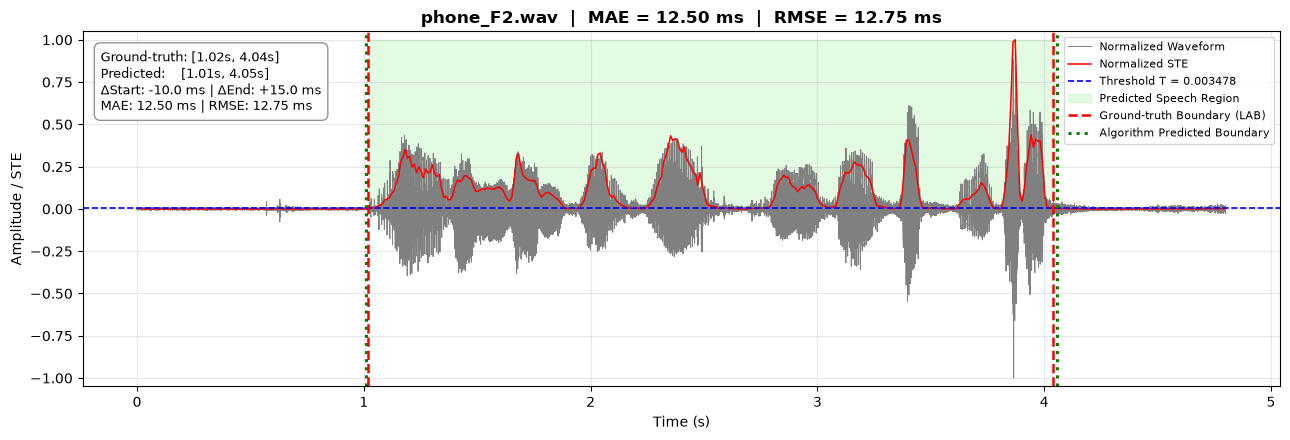

Exported and saved figure: output\main\phone_M2.png


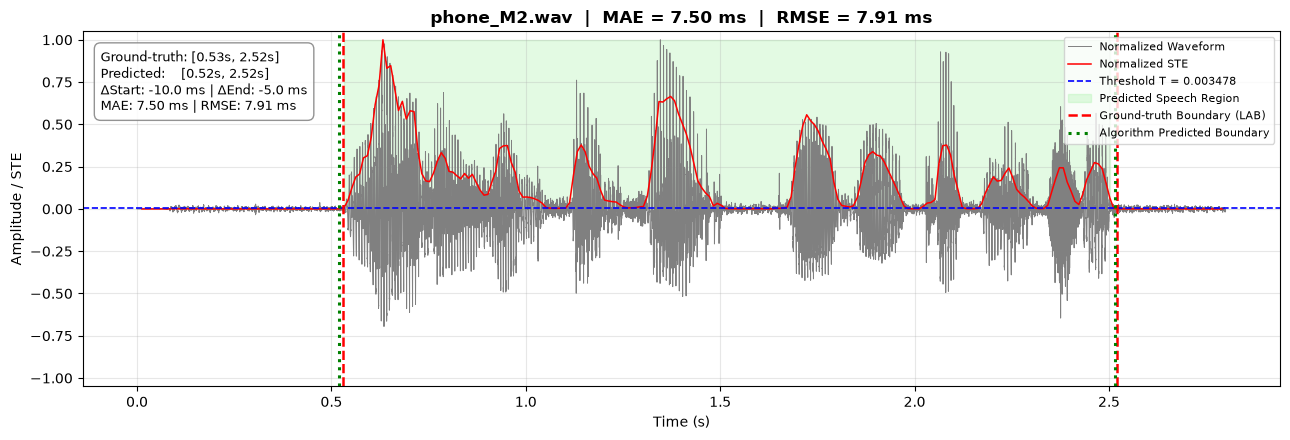

Exported and saved figure: output\main\studio_F2.png


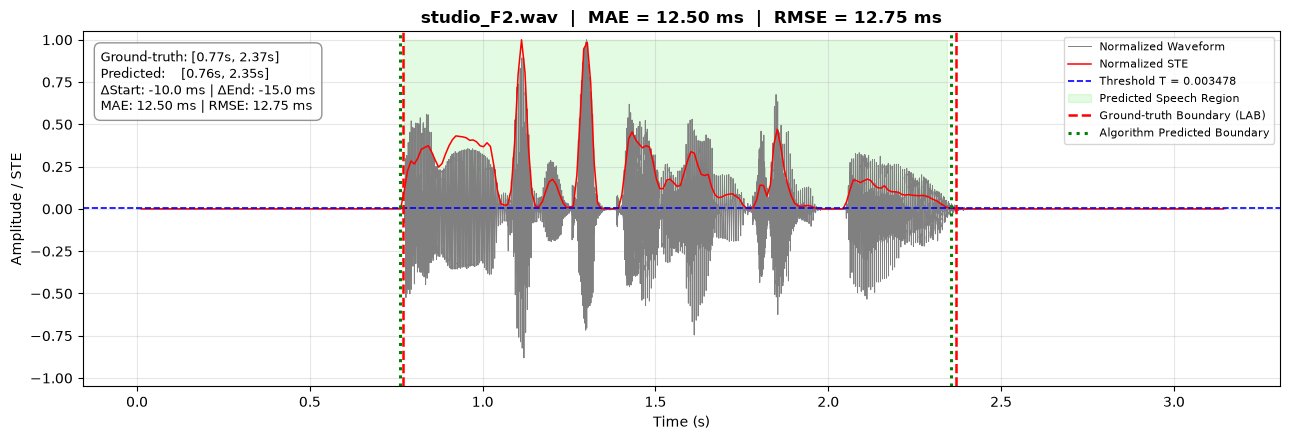

Exported and saved figure: output\main\studio_M2.png


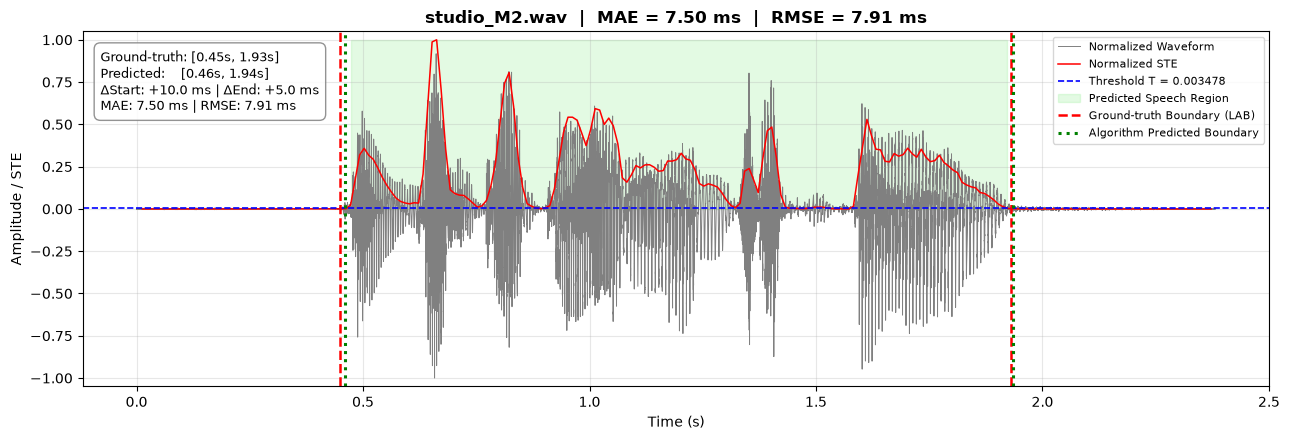

In [5]:
# Cell 5: Export 4 Separate Test Figures with Detailed Parameter and Metrics Box
for res in test_results:
    fig, ax = plt.subplots(figsize=(13, 4.5))
    time_signal = np.arange(len(res["signal"])) / res["fs"]
    frame_centers = res["frame_starts"] + (FRAME_MS / 2000.0)

    # 1. Plot normalized waveform and normalized STE
    ax.plot(time_signal, res["signal"], color="gray", linewidth=0.7, label="Normalized Waveform")
    ax.plot(frame_centers, res["ste_norm"], color="red", linewidth=1.1, label="Normalized STE")
    ax.axhline(model.threshold, color="blue", linestyle="--", linewidth=1.2, label=f"Threshold T = {model.threshold:.6f}")

    # Shade background for predicted speech region
    ax.fill_between(frame_centers, 0, 1, where=res["labels"] == 1, color="lightgreen", alpha=0.25, label="Predicted Speech Region")

    # 2. Draw Ground-truth boundaries (RED dashed) and algorithm boundaries (GREEN dotted)
    ax.axvline(res["gt"][0], color="red", linestyle="--", linewidth=1.8, label="Ground-truth Boundary (LAB)")
    ax.axvline(res["gt"][1], color="red", linestyle="--", linewidth=1.8)
    ax.axvline(res["pred"][0], color="green", linestyle=":", linewidth=2.2, label="Algorithm Predicted Boundary")
    ax.axvline(res["pred"][1], color="green", linestyle=":", linewidth=2.2)

    # Title, axis labels, limits, grid, and legend
    ax.set_title(f"{res['file']}  |  MAE = {res['mae']:.2f} ms  |  RMSE = {res['rmse']:.2f} ms", fontsize=12, fontweight="bold")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude / STE")
    ax.set_ylim(-1.05, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

    # Detailed statistics text box on the plot
    info_text = (
        f"Ground-truth: [{res['gt'][0]:.2f}s, {res['gt'][1]:.2f}s]\n"
        f"Predicted:    [{res['pred'][0]:.2f}s, {res['pred'][1]:.2f}s]\n"
        f"ΔStart: {res['d_start']:+.1f} ms | ΔEnd: {res['d_end']:+.1f} ms\n"
        f"MAE: {res['mae']:.2f} ms | RMSE: {res['rmse']:.2f} ms"
    )
    ax.text(0.015, 0.95, info_text, transform=ax.transAxes, fontsize=9,
            verticalalignment="top", bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85, edgecolor="gray"))

    plt.tight_layout()
    fig_path = OUTPUT_DIR / f"{Path(res['file']).stem}.png"
    plt.savefig(fig_path, dpi=150)
    print(f"Exported and saved figure: {fig_path}")
    plt.show()
